In [3]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from DataTransformationPipeline import RowDataPreprocessingPipeline
from ModelTrainer import ModelTrainerForEachMachineType
from FeatureBuilderForForcasting import WeeklyProfileRecursiveForecaster

from pathlib import Path

In [4]:
BUNDLE_PATH = Path(r"C:\Users\devan\Desktop\SAR_Work\forecasting_ready_bundle.pkl")
bundal = joblib.load(BUNDLE_PATH)

In [5]:
YWNC2_CONE_model = bundal['models']['YWNC2_CONE']
YWNC2_CUP_model = bundal['models']['YWNC2_CUP']
YWNC3_CONE_model = bundal['models']['YWNC3_CONE']
YWNC3_CUP_model = bundal['models']['YWNC3_CUP']

In [6]:
YWNC2_CONE_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

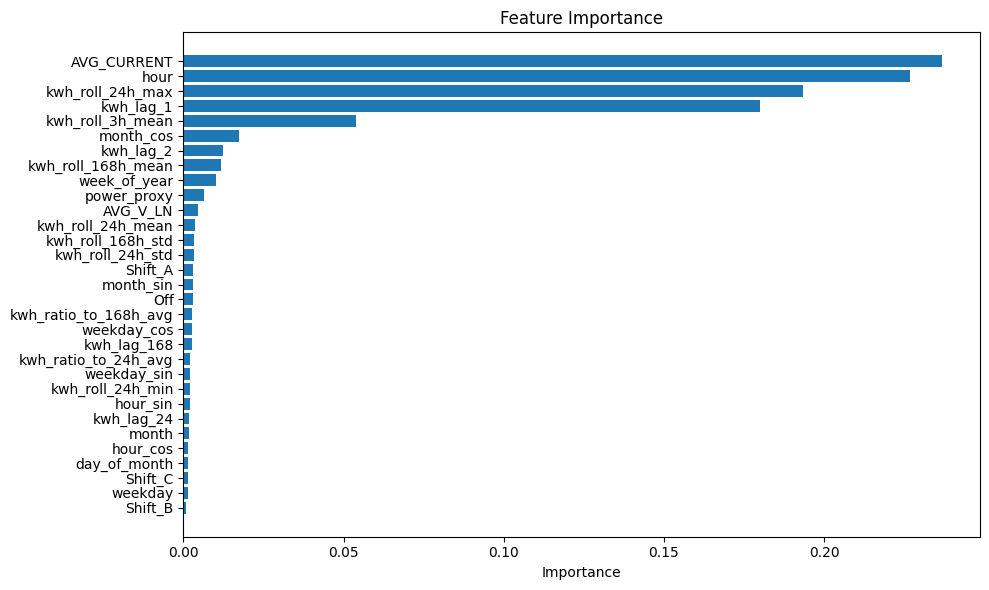

In [7]:
importances = YWNC2_CONE_model.feature_importances_
features = ['AVG_CURRENT', 'AVG_V_LN', 'power_proxy', 'hour', 'weekday',
       'day_of_month', 'month', 'week_of_year', 'hour_sin', 'hour_cos',
       'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'Shift_A',
       'Shift_B', 'Shift_C', 'Off', 'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_24',
       'kwh_lag_168', 'kwh_roll_3h_mean', 'kwh_roll_24h_mean',
       'kwh_roll_24h_std', 'kwh_roll_24h_min', 'kwh_roll_24h_max',
       'kwh_roll_168h_mean', 'kwh_roll_168h_std', 'kwh_ratio_to_24h_avg',
       'kwh_ratio_to_168h_avg']

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [8]:
print("Features:", len(features))
print("Importances:", len(importances))

Features: 31
Importances: 31


In [9]:
path = r"C:\Users\devan\Desktop\SAR_Work\final_df.csv"
final_df = pd.read_csv(path, index_col=0, parse_dates=True) 

In [10]:
final_df.columns

Index(['HOURLY_KWH', 'AVG_CURRENT', 'AVG_V_LN', 'original_data', 'power_proxy',
       'hour', 'weekday', 'month', 'week_of_year', 'hour_sin', 'hour_cos',
       'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'Shift_A',
       'Shift_B', 'Shift_C', 'Off', 'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_24',
       'kwh_lag_168', 'kwh_roll_3h_mean', 'kwh_roll_24h_mean',
       'kwh_roll_24h_std', 'kwh_roll_24h_min', 'kwh_roll_24h_max',
       'kwh_roll_168h_mean', 'kwh_roll_168h_std', 'kwh_ratio_to_24h_avg',
       'kwh_ratio_to_168h_avg', 'Type'],
      dtype='object')

In [11]:
cols = ['HOURLY_KWH', 'AVG_CURRENT', 'AVG_V_LN', 'Off', 'Type', 'Shift_A', 'Shift_B', 'Shift_C', 'weekday']
check_off_df = final_df.loc[((final_df['Off'] == True) & (final_df['Type'] == 'YWNC3 CONE')), cols]

In [12]:
len(final_df['HOURLY_KWH'])

17896

In [13]:
len(final_df['Shift_A'])

17896

In [14]:
check_off_df.isnull().sum()

HOURLY_KWH     0
AVG_CURRENT    0
AVG_V_LN       0
Off            0
Type           0
Shift_A        0
Shift_B        0
Shift_C        0
weekday        0
dtype: int64

In [15]:
check_off_df.iloc[16:32]

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,Off,Type,Shift_A,Shift_B,Shift_C,weekday
Time,,,,,,,,,
2025-08-10 00:00:00,0.093,0.244500,240.068500,1,YWNC3 CONE,0,0,1,6
2025-08-10 01:00:00,0.084,0.243909,240.037455,1,YWNC3 CONE,0,0,1,6
2025-08-10 02:00:00,0.092,0.244000,240.006333,1,YWNC3 CONE,0,0,1,6
2025-08-10 03:00:00,0.083,0.243818,240.021727,1,YWNC3 CONE,0,0,1,6
2025-08-10 04:00:00,0.092,0.243917,240.026833,1,YWNC3 CONE,0,0,1,6
2025-08-10 05:00:00,0.091,0.242750,239.993750,1,YWNC3 CONE,0,0,1,6
2025-08-10 06:00:00,0.084,0.243182,240.033909,1,YWNC3 CONE,0,0,1,6
2025-09-06 10:00:00,0.103,0.440000,239.914800,1,YWNC3 CONE,1,0,0,5
2025-10-02 07:00:00,0.122,0.410875,240.250500,1,YWNC3 CONE,1,0,0,3


In [16]:
check_off_df[check_off_df["HOURLY_KWH"] > 0.4].shape

(0, 9)

In [17]:
check_off_df[check_off_df["HOURLY_KWH"] > 0.4]

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,Off,Type,Shift_A,Shift_B,Shift_C,weekday
Time,,,,,,,,,


# Prediction Graph

In [30]:
path = r"C:\Users\devan\Desktop\SAR_Work\forecast.csv"
df = pd.read_csv(path, index_col=0, parse_dates=True) 

In [31]:
df.head()

,Predicted_KWH,machine_type
Time,,
2026-02-02 07:00:00,1.105947,YWNC2_CONE
2026-02-02 07:00:00,1.217027,YWNC2_CUP
2026-02-02 07:00:00,0.828651,YWNC3_CUP
2026-02-02 07:00:00,0.596650,YWNC3_CONE
2026-02-02 08:00:00,1.290946,YWNC2_CONE


In [32]:
# -----------------------------
# 12. Predict (Random Forest)
# -----------------------------
next_week_2CONE_pred = df[(df['machine_type'] == 'YWNC2_CONE')].drop(columns=['machine_type', 'YWNC2_CONE'], errors='ignore')
next_day_2CONE_pred = df[(df['machine_type'] == 'YWNC2_CONE')].drop(columns=['machine_type', 'YWNC2_CONE'], errors='ignore')

In [33]:
next_day_2CONE_pred.head()

,Predicted_KWH
Time,
2026-02-02 07:00:00,1.105947
2026-02-02 08:00:00,1.290946
2026-02-02 09:00:00,1.308621
2026-02-02 10:00:00,1.268810
2026-02-02 11:00:00,1.231867


In [35]:
# -----------------------------
# 13. Forecast DataFrame
# -----------------------------
forecast_df_day = pd.DataFrame(
    {"Predicted": next_day_2CONE_pred['Predicted_KWH']},
    index=next_day_2CONE_pred.index
)
forecast_df_week = pd.DataFrame(
    {"Predicted": next_week_2CONE_pred['Predicted_KWH']},
    index=next_week_2CONE_pred.index
)

In [36]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df_day.index,
    y=forecast_df_day["Predicted"],
    mode="lines",
    name="Next 7 Days Forecast",
    line=dict(width=2)
))

fig.update_layout(
    title="Next 7 Days Hourly Energy Forecast",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()

In [37]:
daily_forecast = (
    forecast_df_week
    .resample("D")
    .sum()
)

fig.add_trace(go.Bar(
    x=daily_forecast.index,
    y=daily_forecast["Predicted"],
    name="Daily Energy (kWh)",
    opacity=0.6
))

In [39]:
machine_types = df["machine_type"].unique()

for machine in machine_types:
    print(f"Forecasting for: {machine}")

    # Get predictions
    next_day_pred = df[(df['machine_type'] == machine)].drop(
        columns=['machine_type', machine], errors='ignore'
    )

    forecast_df_day = pd.DataFrame(
        {"Predicted": next_day_pred['Predicted_KWH']},
        index=next_day_pred.index
    )

    # -----------------------------
    # Plot only daily forecast (24h line)
    # -----------------------------
    fig_day = go.Figure()

    fig_day.add_trace(go.Scatter(
        x=forecast_df_day.index,
        y=forecast_df_day["Predicted"],
        mode="lines+markers",
        name=f"{machine} – Hourly Forecast",
        line=dict(color='blue', width=2),
        marker=dict(size=6)
    ))

    fig_day.update_layout(
        title=f"{machine} – Next 24h Hourly Forecast",
        xaxis_title="Hour",
        yaxis_title="Energy / Load (kWh)",
        template="plotly_white"
    )

    fig_day.show()

Forecasting for: YWNC2_CONE


Forecasting for: YWNC2_CUP


Forecasting for: YWNC3_CUP


Forecasting for: YWNC3_CONE


In [42]:
for machine in machine_types:
    print(f"Forecasting for: {machine}")
    # -----------------------------
    # 12. Predict (Random Forest)
    # -----------------------------
    next_week_pred = df[(df['machine_type'] == machine)].drop(
        columns=['machine_type', machine], errors='ignore'
    )
    next_day_pred = df[(df['machine_type'] == machine)].drop(
        columns=['machine_type', machine], errors='ignore'
    )
    # -----------------------------
    # 13. Forecast DataFrame
    # -----------------------------
    forecast_df_day = pd.DataFrame(
        {"Predicted": next_day_pred['Predicted_KWH']},
        index=next_day_pred.index
    )
    forecast_df_week = pd.DataFrame(
        {"Predicted": next_week_pred['Predicted_KWH']},
        index=next_week_pred.index
    )
    
    # -----------------------------
    # Custom Daily Aggregation (7 AM to 6 AM next day)
    # -----------------------------
    # Shift the data by 7 hours backward so that 7 AM becomes midnight
    shifted_forecast = forecast_df_week.copy()
    shifted_forecast.index = shifted_forecast.index - pd.Timedelta(hours=7)
    
    # Resample to daily (now each day represents 7 AM to 6 AM of the next day)
    daily_forecast = shifted_forecast.resample("D").sum()
    
    # Shift the index back by 7 hours to display the correct date labels
    daily_forecast.index = daily_forecast.index + pd.Timedelta(hours=7)
    
    # Set the day name based on the starting day (7 AM)
    daily_forecast['day_label'] = daily_forecast.index.strftime('%A')
    
    # -----------------------------
    # Plot
    # -----------------------------
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=forecast_df_day.index,
        y=forecast_df_day["Predicted"],
        mode="lines",
        name=f"{machine} – Next 7 Days (Hourly)",
        line=dict(width=2)
    ))
    
    fig.add_trace(go.Bar(
        x=daily_forecast.index,
        y=daily_forecast["Predicted"],
        name=f"{machine} – Daily Energy (kWh) [7 AM - 6 AM]",
        opacity=0.6,
        text=daily_forecast['day_label'],
        textposition='outside'
    ))
    
    fig.update_layout(
        title=f"{machine} – Energy Forecast",
        xaxis_title="Time",
        yaxis_title="Energy / Load",
        template="plotly_white"
    )
    fig.show()

Forecasting for: YWNC2_CONE


Forecasting for: YWNC2_CUP


Forecasting for: YWNC3_CUP


Forecasting for: YWNC3_CONE


In [26]:
bundle = joblib.load(r"C:\Users\devan\Desktop\SAR_Work\forecasting_ready_bundle.pkl")
models = bundle["models"]
features = bundle["feature_columns"]

In [27]:
def get_feature_importance(models: dict, importance_type="gain", top_n=None):
    """
    Get sorted feature importance for all machine models.

    Args:
        models (dict): {machine_name: trained_model}
        importance_type (str): "gain", "weight", or "cover"
        top_n (int, optional): Return only top N features

    Returns:
        dict: {machine_name: DataFrame(feature, importance)}
    """
    results = {}

    for name, model in models.items():
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        # score keys are already real feature names
        df_imp = (
            pd.DataFrame(list(score.items()), columns=["feature", "importance"])
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        if top_n:
            df_imp = df_imp.head(top_n)

        results[name] = df_imp

    return results

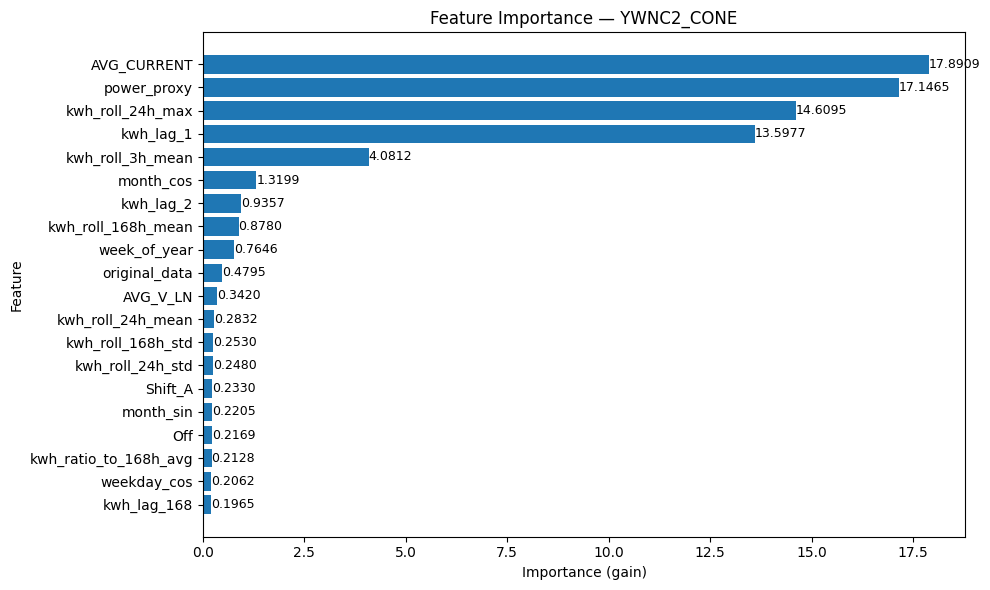

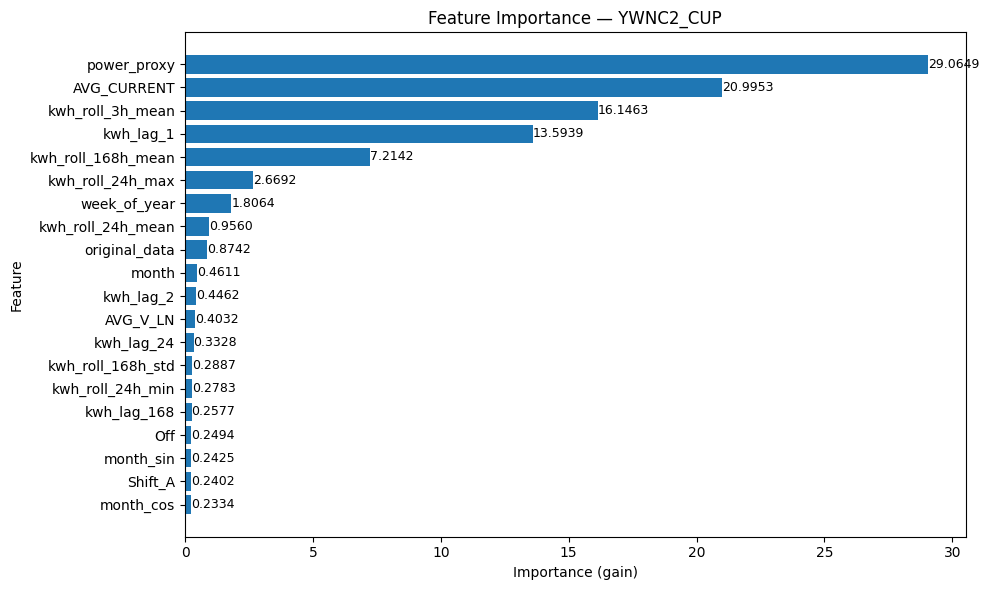

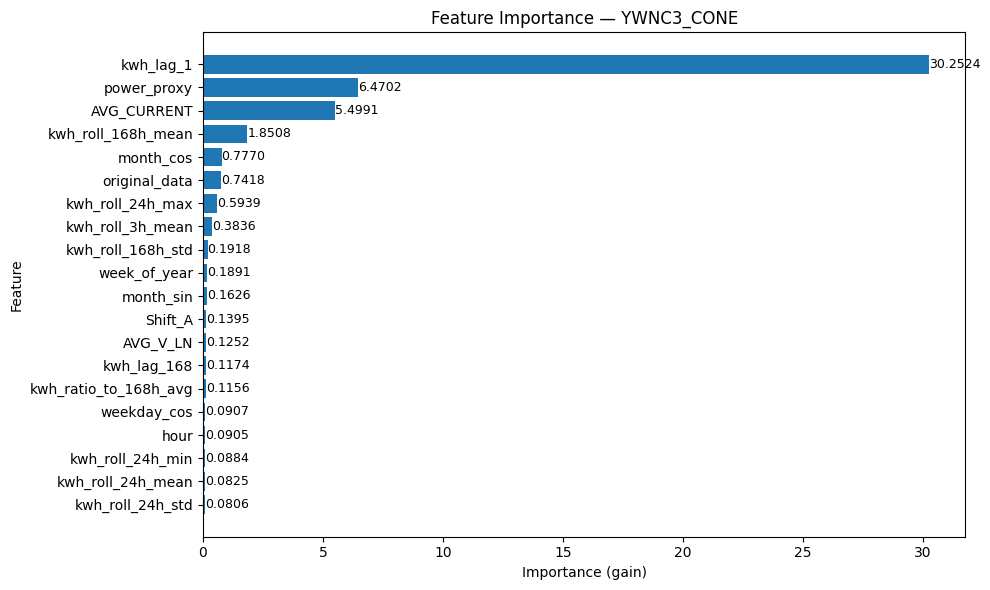

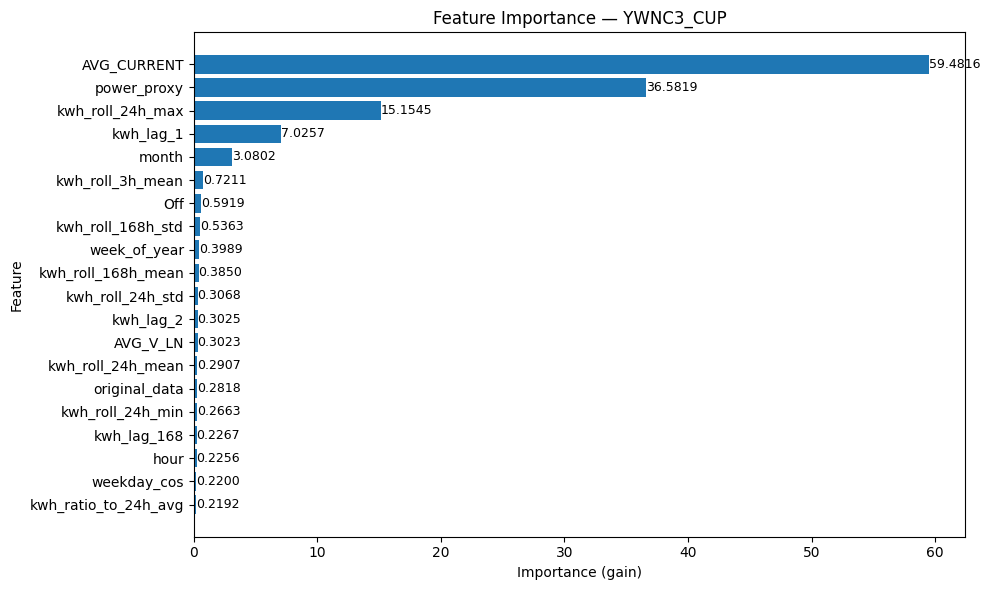

In [28]:
fi_results = get_feature_importance(models, importance_type="gain", top_n=20)

# Display nicely
for machine, df in fi_results.items():
    plt.figure(figsize=(10, 6))
    bars = plt.barh(df["feature"], df["importance"])
    plt.gca().invert_yaxis()  # highest importance on top

    plt.title(f"Feature Importance — {machine}")
    plt.xlabel("Importance (gain)")
    plt.ylabel("Feature")

    # 🔢 Add value labels on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:.4f}",     # format to 4 decimals
            va="center",
            ha="left",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()
